<h1>Introduction</h1>

<p>What makes Formula 1 truly fascinating is the relentless pursuit of performance. Every team constantly searches for marginal gains — whether on track through aerodynamics and driving skill, or off track through strategy, data, and operational excellence. This culture of continuous improvement is what sets Formula 1 apart from many other sports.

One of the most critical yet often overlooked aspects of Formula 1 performance is the pit stop.

Since the beginning of Formula 1, pit stops have played a crucial role in race outcomes. In the early years, pit stops consumed a significant portion of race time. As teams optimized every detail, pit stops became faster, more efficient, and strategically important. Engineers refined equipment, crews trained relentlessly, and governing bodies introduced rule changes to balance performance, strategy, and safety.

Today, Formula 1 pit stops are among the fastest coordinated team operations in sports — often completed in under 2 seconds. Although cars no longer refuel during races and tyre changes are the primary purpose of pit stops, they remain a decisive factor influencing race strategies, track position, and ultimately, race results.</p>

<h1>Objective</h1>

<p>This notebook explores Formula 1 pit stop data to better understand the role pit stops play in a Grand Prix. By analyzing historical pit stop performance, trends, and team efficiency, this study aims to uncover how pit stops influence race outcomes and strategic decisions. Using these findings, the analysis will attempt to answer the questions outlined below, with the goal of providing new perspectives and deeper insights into this critical aspect of Formula 1 racing.</p>

<div align="center">
  <img src="https://c.tenor.com/tg28WEO2hLoAAAAC/f1-pitstop.gif">
</div>

### Setup

In [19]:
import numpy as np 
import pandas as pd 
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt

import os
fnames = []
fpaths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        fnames.append(filename.split('.')[0])
        fpaths.append(os.path.join(dirname, filename))
        print(os.path.join(dirname, filename))

### Reading Data

In [26]:
circuits = pd.read_csv("data/circuits.csv", index_col=0, na_values=r'\N')
constructorResults = pd.read_csv("data/constructor_results.csv", index_col=0, na_values=r'\N')
constructors = pd.read_csv("data/constructors.csv", index_col=0, na_values=r'\N')
constructorStandings = pd.read_csv("data/constructor_standings.csv", index_col=0, na_values=r'\N')
drivers = pd.read_csv("data/drivers.csv", index_col=0, na_values=r'\N')
driverStandings = pd.read_csv("data/driver_standings.csv", index_col=0, na_values=r'\N')
lapTimes = pd.read_csv("data/lap_times.csv")
pitStops = pd.read_csv("data/pit_stops.csv")
qualifying = pd.read_csv("data/qualifying.csv", index_col=0, na_values=r'\N')
races = pd.read_csv("data/races.csv", na_values=r'\N')
results = pd.read_csv("data/results.csv", index_col=0, na_values=r'\N')
seasons = pd.read_csv("data/seasons.csv", index_col=0, na_values=r'\N')
status = pd.read_csv("data/status.csv", index_col=0, na_values=r'\N')

In [27]:
races = races.rename(columns={
    'name':'raceName',
    'url':'raceUrl'
})

races = races[['raceId','year','round','circuitId','raceName','date','time','raceUrl']]

races['date'] = pd.to_datetime(races['date'])

In [28]:
circuits = circuits.rename(columns={'name':'circuitName','location':'circuitLocation','country':'circuitCountry','url':'circuitUrl'})
drivers = drivers.rename(columns={'nationality':'driverNationality','url':'driverUrl'})
drivers['driverName'] = drivers['forename']+' '+drivers['surname']
constructors = constructors.rename(columns={'name':'constructorName','nationality':'constructorNationality','url':'constructorUrl'})
pitStops = pitStops.rename(columns={'time':'pitTime'})
pitStops['seconds'] = pitStops['milliseconds'].apply(lambda x: x/1000)
results['seconds'] = results['milliseconds'].apply(lambda x: x/1000)

In [29]:
# Constructor color mapping
constructor_color_map = {
    'Toro Rosso':'#0000FF',
    'Mercedes':'#6CD3BF',
    'Red Bull':'#1E5BC6',
    'Ferrari':'#ED1C24',
    'Williams':'#37BEDD',
    'Force India':'#FF80C7',
    'Virgin':'#c82e37',
    'Renault':'#FFD800',
    'McLaren':'#F58020',
    'Sauber':'#006EFF',
    'Lotus':'#FFB800',
    'HRT':'#b2945e',
    'Caterham':'#0b361f',
    'Lotus F1':'#FFB800',
    'Marussia':'#6E0000',
    'Manor Marussia':'#6E0000',
    'Haas F1 Team':'#B6BABD',
    'Racing Point':'#F596C8',
    'Aston Martin':'#2D826D',
    'Alfa Romeo':'#B12039',
    'AlphaTauri':'#4E7C9B',
    'Alpine F1 Team':'#2293D1'
}

### Pit-Stop Data

In [30]:
pitStops

,raceId,driverId,stop,lap,pitTime,duration,milliseconds,seconds
0,841,153,1,1,17:05:23,26.898,26898,26.898
1,841,30,1,1,17:05:52,25.021,25021,25.021
2,841,17,1,11,17:20:48,23.426,23426,23.426
3,841,4,1,12,17:22:34,23.251,23251,23.251
4,841,13,1,13,17:24:10,23.842,23842,23.842
...,...,...,...,...,...,...,...,...
11366,1144,840,2,32,17:52:48,22.053,22053,22.053
11367,1144,1,1,34,17:55:17,21.694,21694,21.694
11368,1144,4,2,37,18:00:10,22.437,22437,22.437
11369,1144,855,2,39,18:03:21,28.765,28765,28.765


In [31]:
pitStops.describe().T

,count,mean,std,min,25%,50%,75%,max
raceId,11371.0,981.194882,92.326831,841.000,895.0000,971.000,1065.000,1144.000
driverId,11371.0,549.734500,383.734981,1.000,20.0000,817.000,835.000,862.000
stop,11371.0,1.787969,1.521462,1.000,1.0000,2.000,2.000,70.000
lap,11371.0,25.387389,14.831497,1.000,13.0000,25.000,36.000,78.000
milliseconds,11371.0,85230.495559,310427.261089,12897.000,21937.5000,23606.000,26544.000,3069017.000
seconds,11371.0,85.230496,310.427261,12.897,21.9375,23.606,26.544,3069.017


In [32]:
newResults = pd.merge(results,races,left_on='raceId',right_index=True,how='left')
newResults = pd.merge(newResults,circuits,left_on='circuitId',right_index=True,how='left')
newResults = pd.merge(newResults,constructors,left_on='constructorId',right_index=True,how='left')
newResults = pd.merge(newResults,drivers,left_on='driverId',right_index=True,how='left')
newResults

,raceId,raceId_x,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,constructorUrl,driverRef,number_y,code,forename,surname,dob,driverNationality,driverUrl,driverName
resultId,,,,,,,,,,,,,,,,,,,,,
1,18,18,1,1,22.0,1,1.0,1,1,10.0,...,http://en.wikipedia.org/wiki/McLaren,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,Lewis Hamilton
2,18,18,2,2,3.0,5,2.0,2,2,8.0,...,http://en.wikipedia.org/wiki/BMW_Sauber,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,Nick Heidfeld
3,18,18,3,3,7.0,7,3.0,3,3,6.0,...,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,Nico Rosberg
4,18,18,4,4,5.0,11,4.0,4,4,5.0,...,http://en.wikipedia.org/wiki/Renault_in_Formul...,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,Fernando Alonso
5,18,18,5,1,23.0,3,5.0,5,5,4.0,...,http://en.wikipedia.org/wiki/McLaren,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,Heikki Kovalainen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26760,1144,1144,825,210,20.0,14,16.0,16,16,0.0,...,http://en.wikipedia.org/wiki/Haas_F1_Team,kevin_magnussen,20.0,MAG,Kevin,Magnussen,1992-10-05,Danish,http://en.wikipedia.org/wiki/Kevin_Magnussen,Kevin Magnussen
26761,1144,1144,859,215,30.0,12,17.0,17,17,0.0,...,http://en.wikipedia.org/wiki/RB_Formula_One_Team,lawson,30.0,LAW,Liam,Lawson,2002-02-11,New Zealander,http://en.wikipedia.org/wiki/Liam_Lawson,Liam Lawson
26762,1144,1144,822,15,77.0,9,NaN,R,18,0.0,...,http://en.wikipedia.org/wiki/Sauber_Motorsport,bottas,77.0,BOT,Valtteri,Bottas,1989-08-28,Finnish,http://en.wikipedia.org/wiki/Valtteri_Bottas,Valtteri Bottas


In [33]:
newPitStops = pd.merge(pitStops,races,left_on='raceId',right_index=True,how='left')
newPitStops = pd.merge(newPitStops,circuits,left_on='circuitId',right_index=True,how='left')
newPitStops = pd.merge(newPitStops,newResults[['raceId','driverId','driverName','constructorId','constructorName']],left_on=['raceId','driverId'],right_on=['raceId','driverId'])
newPitStops

,raceId,raceId_x,driverId,stop,lap,pitTime,duration,milliseconds,seconds,raceId_y,...,circuitName,circuitLocation,circuitCountry,lat,lng,alt,circuitUrl,driverName,constructorId,constructorName
0,841,841,153,1,1,17:05:23,26.898,26898,26.898,843.0,...,Shanghai International Circuit,Shanghai,China,31.3389,121.22,5.0,http://en.wikipedia.org/wiki/Shanghai_Internat...,Jaime Alguersuari,5,Toro Rosso
1,841,841,30,1,1,17:05:52,25.021,25021,25.021,843.0,...,Shanghai International Circuit,Shanghai,China,31.3389,121.22,5.0,http://en.wikipedia.org/wiki/Shanghai_Internat...,Michael Schumacher,131,Mercedes
2,841,841,17,1,11,17:20:48,23.426,23426,23.426,843.0,...,Shanghai International Circuit,Shanghai,China,31.3389,121.22,5.0,http://en.wikipedia.org/wiki/Shanghai_Internat...,Mark Webber,9,Red Bull
3,841,841,4,1,12,17:22:34,23.251,23251,23.251,843.0,...,Shanghai International Circuit,Shanghai,China,31.3389,121.22,5.0,http://en.wikipedia.org/wiki/Shanghai_Internat...,Fernando Alonso,6,Ferrari
4,841,841,13,1,13,17:24:10,23.842,23842,23.842,843.0,...,Shanghai International Circuit,Shanghai,China,31.3389,121.22,5.0,http://en.wikipedia.org/wiki/Shanghai_Internat...,Felipe Massa,6,Ferrari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11366,1144,1144,840,2,32,17:52:48,22.053,22053,22.053,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lance Stroll,117,Aston Martin
11367,1144,1144,1,1,34,17:55:17,21.694,21694,21.694,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lewis Hamilton,131,Mercedes
11368,1144,1144,4,2,37,18:00:10,22.437,22437,22.437,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fernando Alonso,117,Aston Martin
11369,1144,1144,855,2,39,18:03:21,28.765,28765,28.765,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Guanyu Zhou,15,Sauber


In [36]:
pitGrouped = newPitStops.groupby(
    ['raceId','raceName','constructorName','driverId','driverName']
).sum(numeric_only=True)

raceResults = pd.merge(
    newResults,
    pitGrouped,
    on=['raceId','driverId'],
    how='left'
)

raceResults['pitPercentage'] = (
    raceResults['milliseconds_y'] /
    raceResults['milliseconds_x'] * 100
)

raceResults

,raceId,raceId_x_x,driverId,constructorId_x,number_x,grid,position,positionText,positionOrder,points,...,seconds_y,raceId_y_y,year_y,round_y,circuitId_y,lat_y,lng_y,alt_y,constructorId_y,pitPercentage
0,18,18,1,1,22.0,1,1.0,1,1,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18,18,2,2,3.0,5,2.0,2,2,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18,18,3,3,7.0,7,3.0,3,3,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,18,4,4,5.0,11,4.0,4,4,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18,18,5,1,23.0,3,5.0,5,5,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,1144,1144,825,210,20.0,14,16.0,16,16,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26755,1144,1144,859,215,30.0,12,17.0,17,17,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26756,1144,1144,822,15,77.0,9,NaN,R,18,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26757,1144,1144,861,3,43.0,20,NaN,R,19,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Analysis

#### How Did Pit Stop Durations Change Over Time?
<ul>
    <li>Average pit stop times showed a noticeable increase from 2013 to 2014</li>
    <li>he majority of pit stop durations fall between 20–35 seconds</li>
    <li>Recent years show higher variance in pit stop durations</li>
    <li>Increased variance suggests:
        <ul>
            <li>More strategic pit stop decisions</li>
            <li>Safety Car / Virtual Safety Car influenced stops</li>
            <li>Operational delays or mistakes</li>
    </li>
</ul>

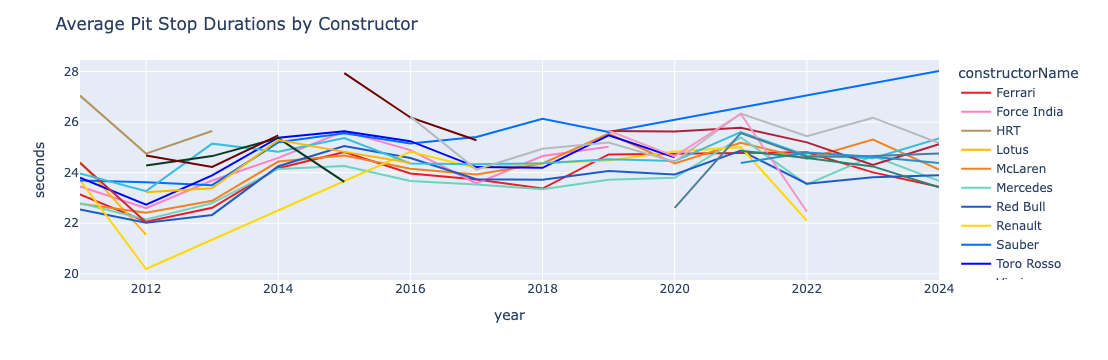

In [38]:
fig = px.line(
    newPitStops[newPitStops['seconds']<50]
    .groupby(['year','constructorName'])['seconds']
    .mean()
    .reset_index(),

    x='year',
    y='seconds',
    color='constructorName',
    color_discrete_map=constructor_color_map,
)

fig.update_layout(
    title='Average Pit Stop Durations by Constructor'
)

fig.show()

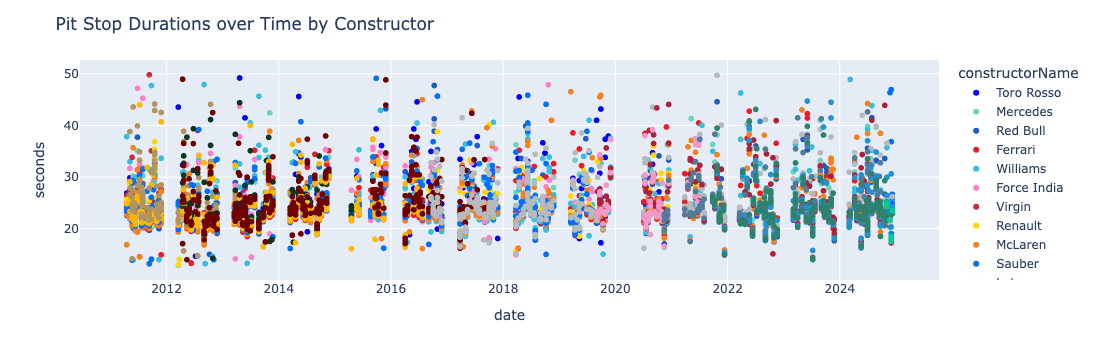

In [39]:
fig = px.scatter(newPitStops[newPitStops['seconds']<50],
                 x='date',
                 y='seconds',
                 color='constructorName',
                 color_discrete_map=constructor_color_map,
                )
fig.update_layout(
    title_text='Pit Stop Durations over Time by Constructor',
)
fig.show()

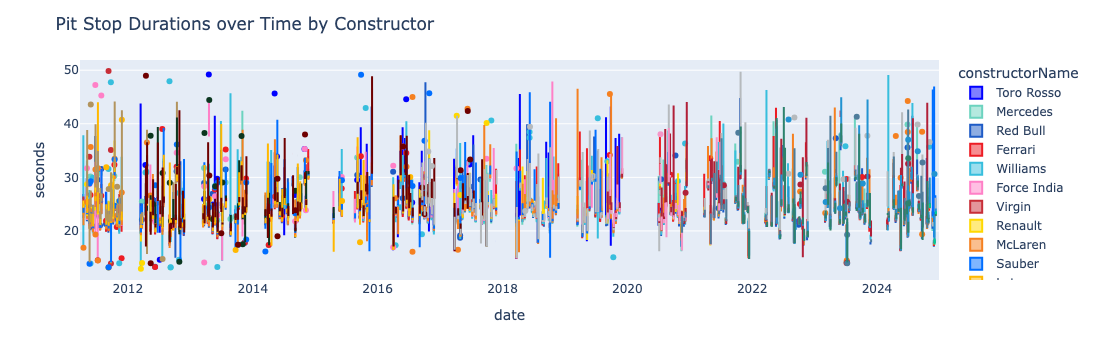

In [40]:
fig = px.box(newPitStops[newPitStops['seconds']<50],
                 x='date',
                 y='seconds',
                 color='constructorName',
                 color_discrete_map=constructor_color_map,
                )
fig.update_layout(
    title_text='Pit Stop Durations over Time by Constructor',
)
fig.show()

<p>Main observations:
    <ul>
        <li>Constructors on average are fairly similar in pit durations</li>
        <li>No significant performance discrepancy. Minor performance variations.</li>
    </ul>
</p>

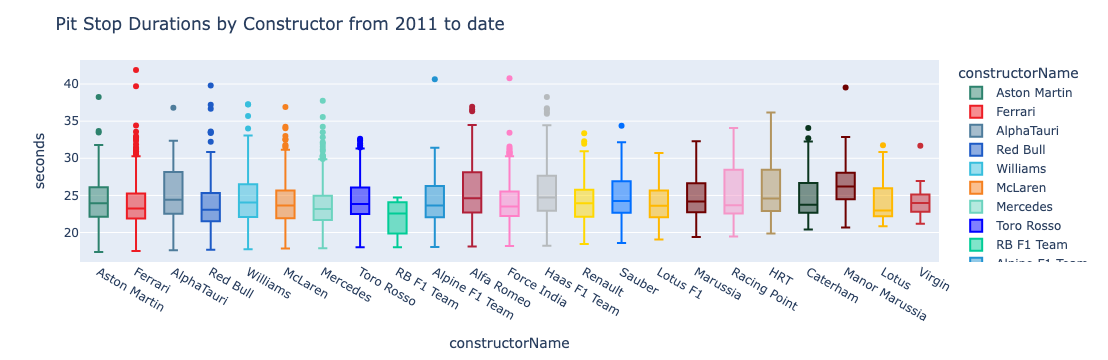

In [42]:
fig = px.box(
    newPitStops[newPitStops['seconds'] < 50]
    .groupby(['raceId','raceName','date','constructorName'])['seconds']
    .mean()
    .reset_index()
    .sort_values(by='seconds', ascending=True),

    x='constructorName',
    y='seconds',
    color='constructorName',
    color_discrete_map=constructor_color_map,
)

fig.update_layout(
    title='Pit Stop Durations by Constructor from 2011 to date'
)

fig.show()

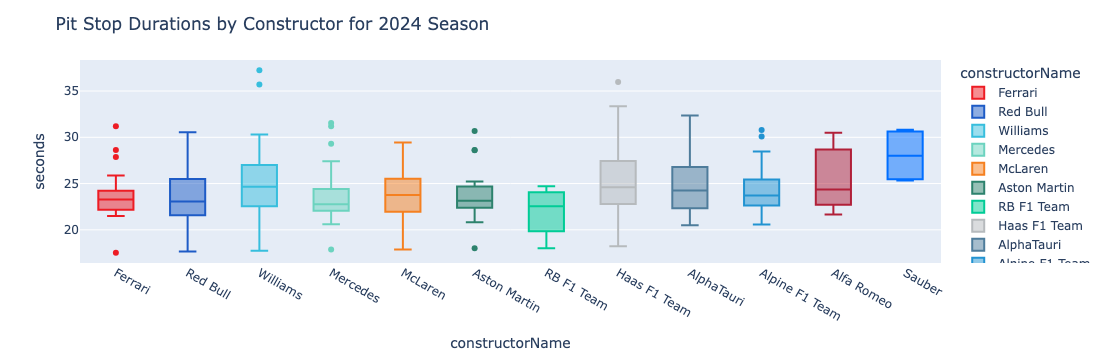

In [71]:
year = 2024

fig = px.box(
    newPitStops[
        (newPitStops['seconds'] < 50) &
        (newPitStops['year'] == year)
    ]
    .groupby(['raceId','raceName','date','constructorName'])['seconds']
    .mean()
    .reset_index()
    .sort_values(by='seconds', ascending=True),

    x='constructorName',
    y='seconds',
    color='constructorName',
    color_discrete_map=constructor_color_map,
)

fig.update_layout(
    title=f'Pit Stop Durations by Constructor for {year} Season'
)

fig.show()

### Is there a relationship between pit stop durations and race circuit?
<p>Main Observations:</p>
<ul>
    <li>Race circuits appear to have a more significant impact on overall pit duration</li>
    <li>Race circuits appear to have an impact on total pit time over the course of the race</li>
    <li>Some circuits have larger variances, but on average the variance from track to track appear to be fairly consistent</li>
</ul>

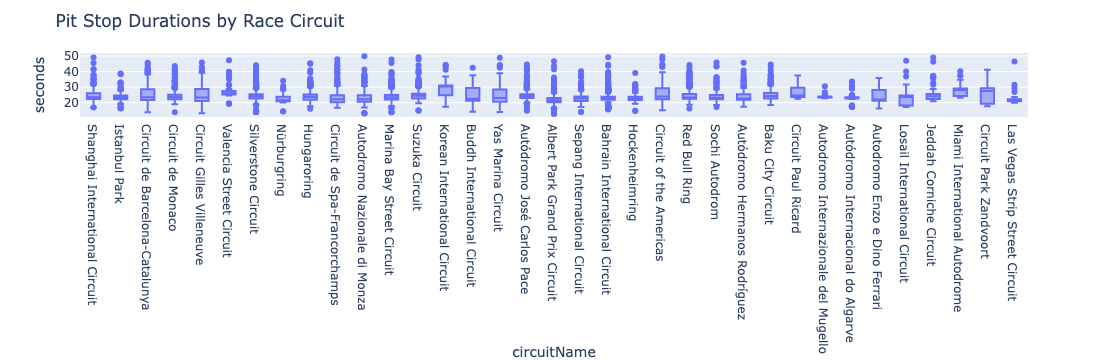

In [47]:
fig = px.box(
    newPitStops[newPitStops['seconds'] < 50],
    x='circuitName',
    y='seconds',
)

fig.update_layout(
    title='Pit Stop Durations by Race Circuit'
)

fig.show()

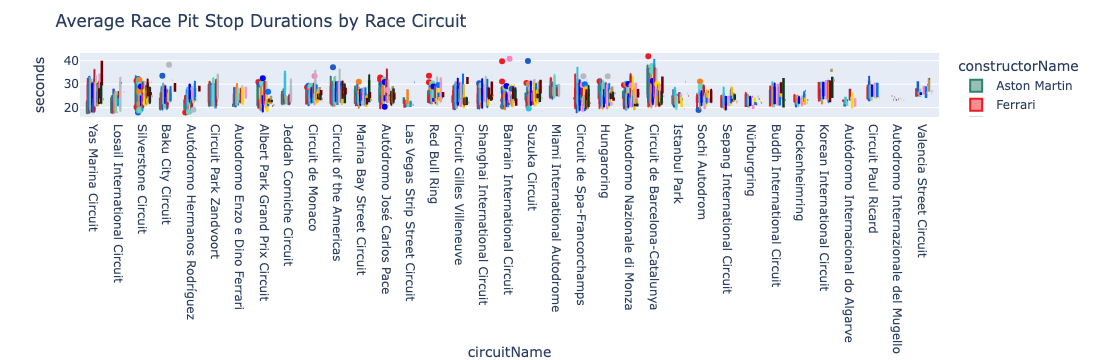

In [52]:
fig = px.box(
    newPitStops[newPitStops['seconds'] < 50]
    .groupby(['raceId','raceName','circuitName','constructorName'])['seconds']
    .mean()
    .reset_index()
    .sort_values(by='seconds', ascending=True),

    x='circuitName',
    y='seconds',
    color='constructorName',
    color_discrete_map=constructor_color_map,
)

fig.update_layout(
    title='Average Race Pit Stop Durations by Race Circuit'
)

fig.show()

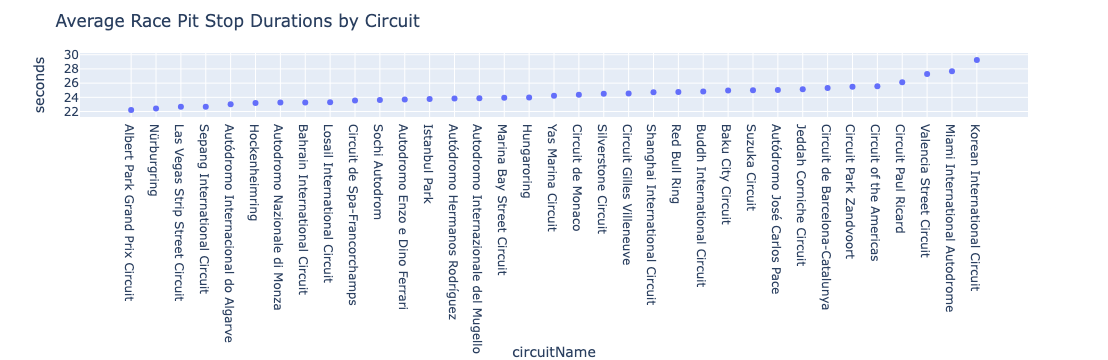

In [53]:
fig = px.scatter(
    newPitStops[newPitStops['seconds'] < 50]
    .groupby('circuitName')['seconds']
    .mean()
    .reset_index()
    .sort_values(by='seconds', ascending=True),

    x='circuitName',
    y='seconds',
)

fig.update_layout(
    title='Average Race Pit Stop Durations by Circuit'
)

fig.show()

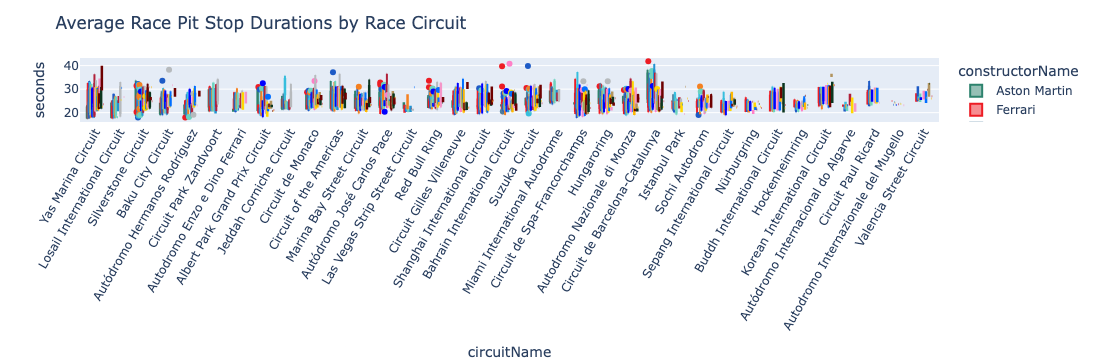

In [51]:
fig = px.box(
    newPitStops[newPitStops['seconds'] < 50]
    .groupby(['raceId','raceName','circuitName','constructorName'])['seconds']
    .mean()
    .reset_index()
    .sort_values(by='seconds', ascending=True),

    x='circuitName',
    y='seconds',
    color='constructorName',
    color_discrete_map=constructor_color_map,
)

fig.update_layout(
    title='Average Race Pit Stop Durations by Race Circuit',
    xaxis_tickangle=-60
)

fig.show()

### Total Time in Pit Lane

In [56]:
newPitStops[newPitStops['seconds'] < 50] \
.groupby(['raceId','circuitName','driverId'])['seconds'].sum() \
.groupby(['raceId','circuitName']).mean() \
.reset_index()

,raceId,circuitName,seconds
0,841,Shanghai International Circuit,52.163190
1,842,Istanbul Park,65.528545
2,843,Circuit de Barcelona-Catalunya,53.889833
3,844,Circuit de Monaco,79.556696
4,845,Circuit Gilles Villeneuve,69.196042
...,...,...,...
260,1120,Autódromo Hermanos Rodríguez,40.712850
261,1121,Autódromo José Carlos Pace,53.535100
262,1122,Las Vegas Strip Street Circuit,24.714412
263,1123,Losail International Circuit,39.432111


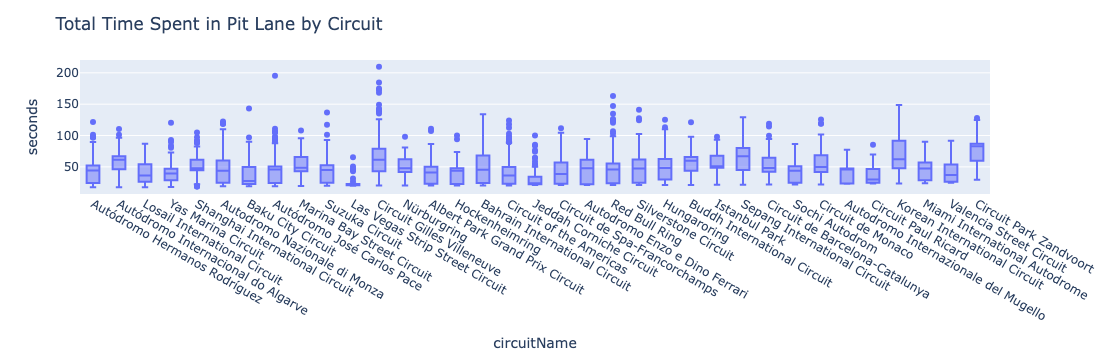

In [57]:
fig = px.box(
    newPitStops[newPitStops['seconds'] < 50]
    .groupby(['raceId','circuitName','driverId'])['seconds']
    .sum()
    .reset_index()
    .sort_values(by='seconds', ascending=True),

    x='circuitName',
    y='seconds',
)

fig.update_layout(
    title='Total Time Spent in Pit Lane by Circuit'
)

fig.show()

### Percentage of race spent in the Pit Lane¶ 
<p>Main Observations:</p>
<ul>
    <li>Findings from pit percentage unsurprisingly are very similar to the average pit time with its correlation to circuit</li>
    <li>There doesn't appear to be much of a correlation between percentage of time in the pit and the race outcome
</li>
</ul>

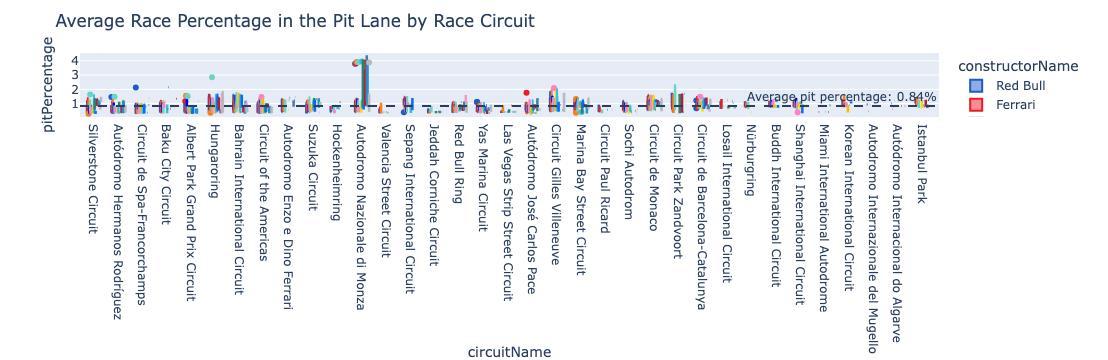

In [58]:
fig = px.box(
    raceResults[raceResults['pitPercentage'] < 10]
    .groupby(['raceId','raceName','circuitName','constructorName'])['pitPercentage']
    .mean()
    .reset_index()
    .sort_values(by='pitPercentage', ascending=True),

    x='circuitName',
    y='pitPercentage',
    color='constructorName',
    color_discrete_map=constructor_color_map,
)

fig.update_layout(
    title='Average Race Percentage in the Pit Lane by Race Circuit'
)

fig.add_hline(
    y=raceResults[raceResults['pitPercentage'] < 10]['pitPercentage'].mean(),
    line_dash='dash',
    annotation_text=f"Average pit percentage: {raceResults[raceResults['pitPercentage'] < 10]['pitPercentage'].mean():.2f}%"
)

fig.show()

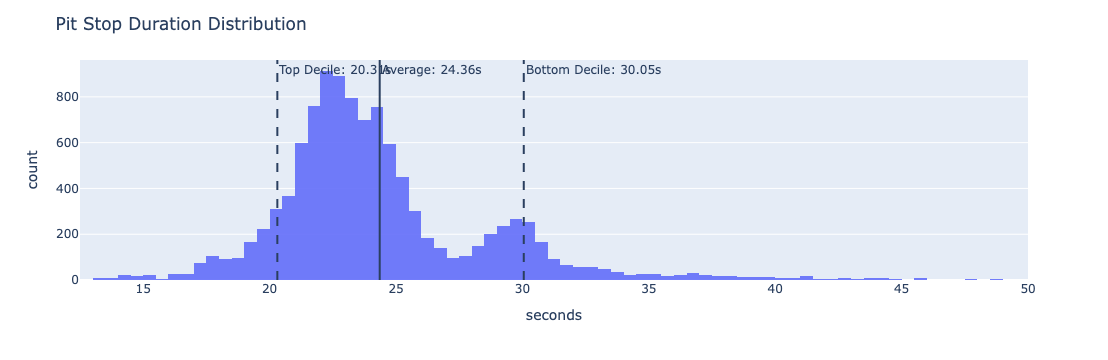

In [59]:
filtered = newPitStops[newPitStops['seconds'] < 50]

fig = px.histogram(
    filtered,
    x='seconds',
)

fig.update_layout(
    title='Pit Stop Duration Distribution'
)

fig.add_vline(
    x=filtered['seconds'].mean(),
    annotation_text=f"Average: {filtered['seconds'].mean():.2f}s"
)

fig.add_vline(
    x=filtered['seconds'].quantile(0.1),
    line_dash='dash',
    annotation_text=f"Top Decile: {filtered['seconds'].quantile(0.1):.2f}s"
)

fig.add_vline(
    x=filtered['seconds'].quantile(0.9),
    line_dash='dash',
    annotation_text=f"Bottom Decile: {filtered['seconds'].quantile(0.9):.2f}s"
)

fig.update_traces(opacity=0.9)

fig.show()

### Who is the Best
<p>
As far as pit stop performance is concerned, <b>speed and consistency</b> appear to be the two key factors that define a great team.
</p>

<ul>
  <li>
    <b>Average pit stop time</b> provides an overall indication of both speed and consistency, serving as an expected performance metric
    <ul>
      <li>A lower average pit time indicates faster and more efficient pit stops</li>
      <li>Teams with consistently fast stops typically maintain lower averages</li>
    </ul>
  </li>

  <li>
    <b>Standard deviation</b> helps evaluate the consistency of a team's pit stop performance
    <ul>
      <li>A lower standard deviation indicates more consistent pit stops</li>
      <li>A higher standard deviation suggests variability due to mistakes, delays, or operational issues</li>
    </ul>
  </li>
</ul>

<p>
Together, <b>average pit stop time</b> and <b>standard deviation</b> provide a strong measure of overall pit stop performance, highlighting both <b>speed</b> and <b>reliability</b>.
</p>

### Ranking on Average Time(2024 Season)

In [72]:
year = 2024


pitStats = (
    newPitStops[
        (newPitStops['seconds'] < 50) &
        (newPitStops['year'] == year)
    ]
    .groupby('constructorName')['seconds']
    .describe()
    .sort_values(by='mean')
)

pitStats

,count,mean,std,min,25%,50%,75%,max
constructorName,,,,,,,,
RB F1 Team,11.0,21.773091,3.122749,17.535,18.39400,23.3580,24.52400,24.988
Aston Martin,87.0,23.419253,3.078556,16.600,22.02150,23.2140,24.60050,33.553
Ferrari,75.0,23.445200,3.330900,16.380,21.84850,23.1970,24.22200,32.888
Mercedes,86.0,23.675326,4.084474,16.415,21.68175,23.0070,24.53475,39.845
Red Bull,92.0,23.902043,4.291250,16.369,21.39650,23.0030,24.82025,41.499
McLaren,86.0,24.117616,4.740963,17.324,21.45925,23.3495,24.84600,44.272
Alpine F1 Team,81.0,24.380185,3.800492,16.380,22.16000,23.9000,25.83300,37.037
AlphaTauri,74.0,24.758811,4.494557,16.246,21.96250,23.4975,27.73475,42.641
Alfa Romeo,73.0,25.125753,4.630400,17.130,22.34500,24.0450,28.70900,43.914


### Ranking on Consistency(2024 Season)

In [69]:
year = 2024

pitConsistency = (
    newPitStops[
        (newPitStops['seconds'] < 50) &
        (newPitStops['year'] == year)
    ]
    .groupby('constructorName')['seconds']
    .describe()
    .sort_values(by='std')
)

pitConsistency

,count,mean,std,min,25%,50%,75%,max
constructorName,,,,,,,,
Aston Martin,87.0,23.419253,3.078556,16.600,22.02150,23.2140,24.60050,33.553
RB F1 Team,11.0,21.773091,3.122749,17.535,18.39400,23.3580,24.52400,24.988
Ferrari,75.0,23.445200,3.330900,16.380,21.84850,23.1970,24.22200,32.888
Alpine F1 Team,81.0,24.380185,3.800492,16.380,22.16000,23.9000,25.83300,37.037
Mercedes,86.0,23.675326,4.084474,16.415,21.68175,23.0070,24.53475,39.845
Red Bull,92.0,23.902043,4.291250,16.369,21.39650,23.0030,24.82025,41.499
AlphaTauri,74.0,24.758811,4.494557,16.246,21.96250,23.4975,27.73475,42.641
Alfa Romeo,73.0,25.125753,4.630400,17.130,22.34500,24.0450,28.70900,43.914
Haas F1 Team,90.0,25.166789,4.649096,16.778,22.29275,24.2540,26.05900,41.972


<h2>Conclusions</h2>

<p>
Pit stops are one of the most exciting and iconic elements of Formula 1, playing an important strategic role during races. However, based on this analysis, optimizing pit stop performance alone may not significantly impact overall race outcomes in the current era. On average, pit stop time accounts for <b>less than 1% of total race time (approximately 0.83%)</b>, suggesting that teams may gain greater performance advantages by focusing on other areas such as car performance, strategy, and driver execution.
</p>

<h3>Key Findings</h3>

<h3>How did pit stop durations change over time?</h3>
<ul>
  <li>Average pit stop durations increased after 2013</li>
  <li>Since 2014, pit stop durations have remained relatively stable</li>
  <li>Variance in pit stop times has increased in recent years</li>
  <li>Increased variance may be influenced by:
    <ul>
      <li>Strategic pit stop variations</li>
      <li>Safety car and virtual safety car situations</li>
      <li>Operational delays and race conditions</li>
    </ul>
  </li>
</ul>

<h3>Is there a relationship between pit stop durations and constructor?</h3>
<ul>
  <li>No strong or meaningful relationship was observed</li>
  <li>Some constructors demonstrate slightly faster pit stops</li>
  <li>Differences between teams do not significantly impact race outcomes</li>
  <li>Pit stop performance alone is not a primary differentiator between constructors</li>
</ul>

<h3>Is there a relationship between pit stop durations and race circuit?</h3>
<ul>
  <li>Race circuits do influence pit stop duration</li>
  <li>Factors contributing to this include:
    <ul>
      <li>Pit lane length</li>
      <li>Track layout</li>
      <li>Number of pit stops required</li>
      <li>Pit lane speed limits</li>
    </ul>
  </li>
  <li>Some circuits naturally result in longer total pit lane time than others</li>
</ul>

<h3>What is the time spent in the pit lane as a percentage of the race?</h3>
<ul>
  <li>Average time spent in the pit lane accounts for approximately <b>0.83%</b> of total race time</li>
  <li>This suggests that while pit stops are strategically important, their direct time impact is relatively small</li>
</ul>

<h3>Final Takeaway</h3>
<ul>
  <li>Pit stops remain a strategically important aspect of Formula 1</li>
  <li>Their overall time impact is relatively small compared to other performance factors</li>
  <li>Teams may achieve greater competitive advantages by optimizing:
    <ul>
      <li>Car performance</li>
      <li>Race strategy</li>
      <li>Tire management</li>
      <li>Driver performance</li>
    </ul>
  </li>
</ul>

<img src="https://static01.nyt.com/athletic/uploads/wp/2025/06/01134736/GettyImages-2218103873-scaled.jpg">